In [1]:
import sys
print(sys.executable)

/Users/shirley/Documents/AI/Projects/product-voice-analytics/.venv/bin/python


In [4]:
import os

# Move to repo root if running from notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(os.getcwd())  # confirm it's now repo root

/Users/shirley/Documents/AI/Projects/product-voice-analytics


# 02 — Baseline Model: TF-IDF + Logistic Regression

Goal: Establish a fast, interpretable baseline before moving to transformers.

This notebook covers:
1. Preprocessing the sampled dataset
2. TF-IDF vectorization
3. Logistic Regression training
4. Evaluation and error analysis
5. Saving the model for comparison later

In [8]:
import pandas as pd
import numpy as np
import pickle
import re
import string
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

STOPWORDS = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shirley/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Load Data

Using the stratified 100K sample generated by `src/pipeline/sampling.py`.

In [6]:
df = pd.read_csv("data/processed/sample_100k.csv")
print(f"Shape: {df.shape}")
print(df['overall'].value_counts().sort_index())

Shape: (100000, 4)
overall
1.0    13563
2.0     6437
3.0    10000
4.0    14399
5.0    55601
Name: count, dtype: int64


## Preprocessing

In [9]:
def clean_text(text):
    is_valid_string = isinstance(text, str)
    if not is_valid_string:
        return ""

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]

    return ' '.join(tokens)

def map_sentiment(rating):
    is_negative = rating <= 2
    is_neutral  = rating == 3

    if is_negative: return 0
    elif is_neutral: return 1
    else: return 2

print("Cleaning text...")
df['clean_text'] = df['reviewText'].apply(clean_text)
df['label']      = df['overall'].apply(map_sentiment)
df = df[df['clean_text'].str.strip() != '']
print(f"After cleaning: {len(df)} rows")

Cleaning text...
After cleaning: 99854 rows


## Train / Test Split

In [10]:
# hint: 80/20 split, stratify on label for balanced classes, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 79883 | Test: 19971


## TF-IDF Vectorization

In [11]:
vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), min_df=3)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Feature matrix shape: {X_train_vec.shape}")

Vocabulary size: 50000
Feature matrix shape: (79883, 50000)


## Train Logistic Regression

In [13]:
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_train_vec, y_train)
print("Training complete.")

Training complete.


## Evaluation

In [15]:
y_pred = model.predict(X_test_vec)

label_names = ['negative', 'neutral', 'positive']
print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

    negative       0.77      0.75      0.76      3998
     neutral       0.44      0.11      0.18      1997
    positive       0.86      0.96      0.91     13976

    accuracy                           0.84     19971
   macro avg       0.69      0.61      0.62     19971
weighted avg       0.80      0.84      0.81     19971



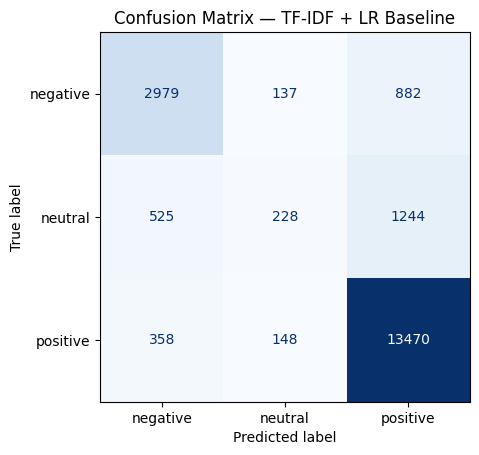

In [16]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — TF-IDF + LR Baseline')
plt.show()

## Most Informative Features

What words most strongly drive each sentiment prediction?

In [17]:
feature_names = vectorizer.get_feature_names_out()
n = 15

for i, label in enumerate(label_names):
    top_feature_indices = np.argsort(model.coef_[i])[-n:][::-1]
    top_feature_names   = [feature_names[j] for j in top_feature_indices]
    print(f"\nTop {n} features for '{label}':")
    print(top_feature_names)


Top 15 features for 'negative':
['useless', 'waste', 'terrible', 'return', 'worst', 'junk', 'disappointed', 'garbage', 'returning', 'horrible', 'returned', 'poor', 'broke', 'unusable', 'stopped']

Top 15 features for 'neutral':
['however', 'three stars', 'okay', 'alright', 'decent', 'though', 'annoying', 'well enough', 'isnt', 'sure', 'bit', 'otherwise', 'except', 'hoping', 'hope']

Top 15 features for 'positive':
['love', 'great', 'perfect', 'excellent', 'perfectly', 'awesome', 'amazing', 'pleased', 'easy', 'best', 'fantastic', 'exactly', 'loves', 'go wrong', 'nice']


## Save Model

In [18]:
import os
os.makedirs('models', exist_ok=True)

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('models/lr_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Saved to models/")

Saved to models/


## Notes for Comparison

- Record accuracy and F1 here once run
- This is the benchmark DistilBERT needs to beat to justify added complexity
- Key weakness: no understanding of word order or context ('not good' vs 'good' handled only via bigrams)